<a href="https://colab.research.google.com/github/Akshitha2403/Real-Time-Face-Mask-Detection-/blob/main/Real_Time_Face_Mask_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Set Kaggle username and API token (YOU MUST CHANGE THESE)
KAGGLE_USERNAME = "akshitharr"      # <-- replace with your Kaggle username
KAGGLE_API_KEY = "KGAT_750a11b4501eaf0e7ca791c811346f5c"        # <-- replace with your Kaggle API key

# Do NOT change the rest of this cell
import os
import json

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_config = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_API_KEY
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle API configured.")
print(f"Username: {KAGGLE_USERNAME}")

Kaggle API configured.
Username: akshitharr


In [ ]:
# Cell 2 (fixed): Verify Kaggle login and install packages
!kaggle config view
!pip install -q ultralytics opencv-python-headless kaggle

Configuration values from /root/.kaggle
- username: akshitharr
- auth_method: LEGACY_API_KEY
- path: None
- proxy: None
- competition: None


In [ ]:
# Cell 3: Download Face Mask Detection Dataset from Kaggle
KAGGLE_DATASET_NAME = "andrewmvd/face-mask-detection"  # normally no change needed

!mkdir -p datasets
!kaggle datasets download -d {KAGGLE_DATASET_NAME} -p datasets/

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
100% 398M/398M [00:02<00:00, 145MB/s]



In [ ]:
# Cell 4: Unzip the dataset
!unzip -q datasets/face-mask-detection.zip -d datasets/

# Show structure
!ls -l datasets/

total 407276
drwxr-xr-x 2 root root     36864 May 30 06:06 annotations
-rw-r--r-- 1 root root 416968083 May 22  2020 face-mask-detection.zip
drwxr-xr-x 2 root root     36864 May 30 06:06 images


In [ ]:
# Diagnostic cell: Check what's inside datasets/
!ls -l datasets/
!find datasets/ -type d | head -20

total 407276
drwxr-xr-x 2 root root     36864 May 30 06:06 annotations
-rw-r--r-- 1 root root 416968083 May 22  2020 face-mask-detection.zip
drwxr-xr-x 2 root root     36864 May 30 06:06 images
datasets/
datasets/images
datasets/annotations


In [ ]:
# Cell 5 (corrected): Inspect dataset structure
!ls -l datasets/
!ls -l datasets/images/ | head
!ls -l datasets/annotations/ | head

total 407276
drwxr-xr-x 2 root root     36864 May 30 06:06 annotations
-rw-r--r-- 1 root root 416968083 May 22  2020 face-mask-detection.zip
drwxr-xr-x 2 root root     36864 May 30 06:06 images
total 408240
-rw-r--r-- 1 root root 329899 May 22  2020 maksssksksss0.png
-rw-r--r-- 1 root root 543200 May 22  2020 maksssksksss100.png
-rw-r--r-- 1 root root 274025 May 22  2020 maksssksksss101.png
-rw-r--r-- 1 root root 514230 May 22  2020 maksssksksss102.png
-rw-r--r-- 1 root root 690476 May 22  2020 maksssksksss103.png
-rw-r--r-- 1 root root 638540 May 22  2020 maksssksksss104.png
-rw-r--r-- 1 root root 557933 May 22  2020 maksssksksss105.png
-rw-r--r-- 1 root root 421698 May 22  2020 maksssksksss106.png
-rw-r--r-- 1 root root 194146 May 22  2020 maksssksksss107.png
total 3844
-rw-r--r-- 1 root root  1252 May 22  2020 maksssksksss0.xml
-rw-r--r-- 1 root root  1245 May 22  2020 maksssksksss100.xml
-rw-r--r-- 1 root root   571 May 22  2020 maksssksksss101.xml
-rw-r--r-- 1 root root   571 May 

In [ ]:
# Cell 6 (updated): Convert dataset to YOLO format with train/val/test split
import os
import xml.etree.ElementTree as ET
from pathlib import Path
import shutil
import random
from tqdm import tqdm
import cv2

# Paths (CORRECTED: dataset is directly in datasets/)
RAW_DATA_DIR = Path("datasets")
IMAGES_DIR = RAW_DATA_DIR / "images"
ANNOTATIONS_DIR = RAW_DATA_DIR / "annotations"

# Output dataset root
DATASET_ROOT = Path("dataset")
IMG_DIR = DATASET_ROOT / "images"
LBL_DIR = DATASET_ROOT / "labels"

TRAIN_DIR_IMG = IMG_DIR / "train"
VAL_DIR_IMG = IMG_DIR / "val"
TEST_DIR_IMG = IMG_DIR / "test"

TRAIN_DIR_LBL = LBL_DIR / "train"
VAL_DIR_LBL = LBL_DIR / "val"
TEST_DIR_LBL = LBL_DIR / "test"

# Create directories
for d in [TRAIN_DIR_IMG, VAL_DIR_IMG, TEST_DIR_IMG,
          TRAIN_DIR_LBL, VAL_DIR_LBL, TEST_DIR_LBL]:
    d.mkdir(parents=True, exist_ok=True)

# Classes: order must match data.yaml later
CLASS_NAMES = ["with_mask", "without_mask"]
CLASS_DICT = {name: idx for idx, name in enumerate(CLASS_NAMES)}

# List all image files
image_files = list(IMAGES_DIR.glob("*.jpg")) + list(IMAGES_DIR.glob("*.png"))
print(f"Total images found: {len(image_files)}")

# Convert annotations
def xml_to_yolo(xml_path, image_width, image_height):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    objects = []
    for obj in root.findall("object"):
        class_name = obj.find("name").text
        if class_name not in CLASS_DICT:
            continue
        cls_id = CLASS_DICT[class_name]

        bbox = obj.find("bndbox")
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = (xmin + xmax) / (2.0 * image_width)
        y_center = (ymin + ymax) / (2.0 * image_height)
        width = (xmax - xmin) / image_width
        height = (ymax - ymin) / image_height

        objects.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    return objects

# Split ratios: 70% train, 15% val, 15% test
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
# test = rest

random.seed(42)
image_files_sorted = sorted(image_files)
random.shuffle(image_files_sorted)

n = len(image_files_sorted)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_images = image_files_sorted[:train_end]
val_images = image_files_sorted[train_end:val_end]
test_images = image_files_sorted[val_end:]

print(f"Train images: {len(train_images)}")
print(f"Val images: {len(val_images)}")
print(f"Test images: {len(test_images)}")

def process_images(image_list, target_img_dir, target_lbl_dir, split_name):
    for img_path in tqdm(image_list, desc=f"Processing {split_name}"):
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Warning: Could not read image {img_path}")
            continue
        h, w = img.shape[:2]

        img_name = img_path.name
        lbl_name = img_path.stem + ".txt"

        dst_img_path = target_img_dir / img_name
        dst_lbl_path = target_lbl_dir / lbl_name

        shutil.copy(img_path, dst_img_path)

        xml_path = ANNOTATIONS_DIR / img_name.replace(".jpg", ".xml").replace(".png", ".xml")
        if not xml_path.exists():
            continue

        yolo_lines = xml_to_yolo(xml_path, w, h)
        with open(dst_lbl_path, "w") as f:
            for line in yolo_lines:
                f.write(line + "\n")

process_images(train_images, TRAIN_DIR_IMG, TRAIN_DIR_LBL, "train")
process_images(val_images, VAL_DIR_IMG, VAL_DIR_LBL, "val")
process_images(test_images, TEST_DIR_IMG, TEST_DIR_LBL, "test")

# Create data.yaml with train, val, test
data_yaml = f"""train: {TRAIN_DIR_IMG.absolute()}
val: {VAL_DIR_IMG.absolute()}
test: {TEST_DIR_IMG.absolute()}

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""

data_yaml_path = DATASET_ROOT / "data.yaml"
with open(data_yaml_path, "w") as f:
    f.write(data_yaml)

print("YOLO dataset created at:", DATASET_ROOT.absolute())
print("data.yaml path:", data_yaml_path.absolute())
!cat {data_yaml_path}

Total images found: 853
Train images: 597
Val images: 128
Test images: 128


Processing test: 100%|██████████| 128/128 [00:02<00:00, 61.12it/s]


YOLO dataset created at: /content/dataset
data.yaml path: /content/dataset/data.yaml
train: /content/dataset/images/train
val: /content/dataset/images/val
test: /content/dataset/images/test

nc: 2
names: ['with_mask', 'without_mask']


In [ ]:
# Cell 7: Load YOLOv8n pretrained model
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # pretrained on COCO
print("Model loaded:", model)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded: YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
     

In [ ]:
# Cell 8: Train YOLOv8n with transfer learning
data_yaml_path = "dataset/data.yaml"

results = model.train(
    data=data_yaml_path,
    epochs=30,        # <-- you can change this
    imgsz=640,        # image size
    batch=16,         # batch size
    name="face_mask_yolov8n",
    exist_ok=True,
    device=0          # use GPU (0)
)

print("Training completed.")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=face_mask_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

In [ ]:
# Cell 9: Evaluate model on validation set
results_val = model.val()
print("Validation results:", results_val)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4118.0±1118.7 MB/s, size: 423.4 KB)
val: Scanning /content/dataset/labels/val.cache... 256 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 256/256 82.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.3it/s 7.0s
                   all        256       1115      0.873      0.885      0.928      0.647
             with_mask        233        919       0.91      0.939      0.967      0.693
          without_mask         85        196      0.836      0.831      0.888      0.601
Speed: 3.0ms preprocess, 8.4ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val
Validation results: ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array

In [ ]:
# Cell 10: Evaluate model on TEST set
results_test = model.val(data="dataset/data.yaml", split="test")
print("Test set results:", results_test)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2333.0±798.7 MB/s, size: 479.7 KB)
val: Scanning /content/dataset/labels/test... 128 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 850.6it/s 0.2s
val: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.8it/s 4.4s
                   all        128        535      0.858      0.873      0.907      0.603
             with_mask        116        461      0.896      0.909      0.955      0.668
          without_mask         41         74       0.82      0.838       0.86      0.538
Speed: 3.5ms preprocess, 6.4ms inference, 0.0ms loss, 6.4ms postprocess per image
Results saved to /content/runs/detect/val-2
Test set results: ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.uti

In [ ]:
# Cell 11 (fixed & simplified): Overall model accuracy and evaluation metrics
from ultralytics import YOLO

best_model_path = "runs/detect/face_mask_yolov8n/weights/best.pt"
model_trained = YOLO(best_model_path)

print("=== MODEL EVALUATION ON VALIDATION SET ===\n")

# Validate on val set (model remembers training data by default)
results = model_trained.val()

# Overall metrics (these are scalars, no indexing needed)
precision = results.box.mp       # precision
recall = results.box.mr          # recall
mAP50 = results.box.map50        # mAP50 (main accuracy metric)
mAP50_95 = results.box.map       # mAP50-95 (stricter accuracy)

print("Overall Model Metrics:")
print(f"  Precision:  {precision:.4f}")
print(f"  Recall:     {recall:.4f}")
print(f"  mAP50:      {mAP50:.4f}  ← main accuracy metric")
print(f"  mAP50-95:   {mAP50_95:.4f}")

print("\nInterpretation:")
print(f"  - mAP50 = {mAP50*100:.2f}% → overall detection accuracy at IoU=0.50")
print(f"  - Precision = {precision*100:.2f}% → of all detected faces, this % were correct")
print(f"  - Recall = {recall*100:.2f}% → of all real faces, this % were detected")

=== MODEL EVALUATION ON VALIDATION SET ===

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5651.4±1084.7 MB/s, size: 472.6 KB)
val: Scanning /content/dataset/labels/val.cache... 256 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 256/256 76.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.3it/s 7.1s
                   all        256       1115      0.873      0.885      0.928      0.647
             with_mask        233        919       0.91      0.939      0.967      0.693
          without_mask         85        196      0.836      0.831      0.888      0.601
Speed: 2.5ms preprocess, 4.2ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/runs/detect/val-5
Overall Model Metrics:
  Precision:  0.8730
  Recall:    

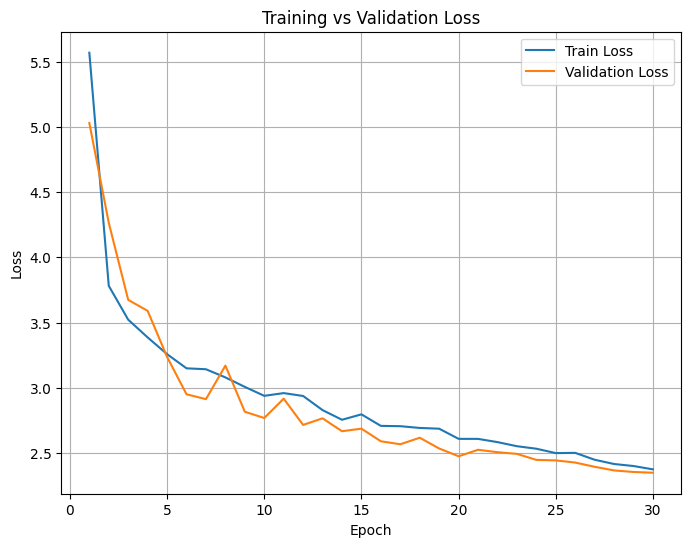

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("runs/detect/face_mask_yolov8n/results.csv")

epochs = range(1, len(df)+1)

train_loss = (
    df['train/box_loss']
    + df['train/cls_loss']
    + df['train/dfl_loss']
)

val_loss = (
    df['val/box_loss']
    + df['val/cls_loss']
    + df['val/dfl_loss']
)

plt.figure(figsize=(8,6))
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

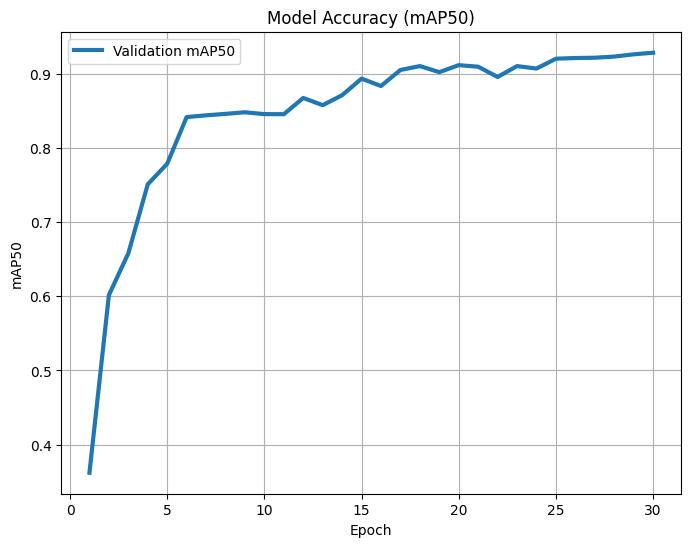

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("runs/detect/face_mask_yolov8n/results.csv")

epochs = range(1, len(df)+1)

plt.figure(figsize=(8,6))

plt.plot(
    epochs,
    df['metrics/mAP50(B)'],
    linewidth=3,
    label='Validation mAP50'
)

plt.title("Model Accuracy (mAP50)")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.legend()
plt.grid(True)

plt.show()

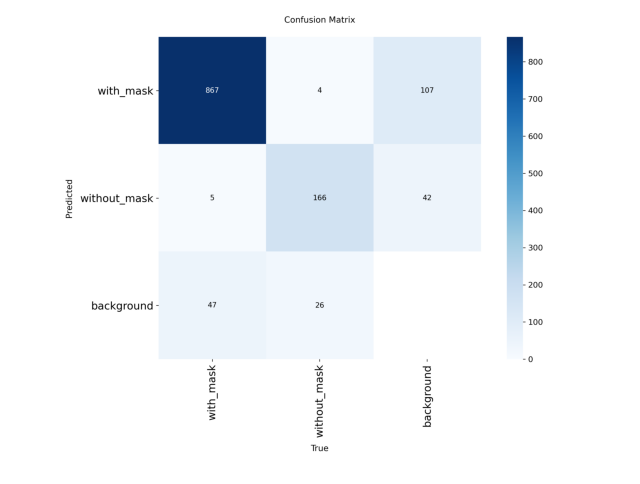

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(
    "runs/detect/face_mask_yolov8n/confusion_matrix.png"
)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

Testing on RANDOM TEST image: dataset/images/test/maksssksksss848.png

image 1/1 /content/dataset/images/test/maksssksksss848.png: 448x640 3 with_masks, 6.4ms
Speed: 1.8ms preprocess, 6.4ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

=== PREDICTIONS ===
Class: with_mask, Confidence: 0.86 (86%)
Class: with_mask, Confidence: 0.84 (84%)
Class: with_mask, Confidence: 0.74 (74%)


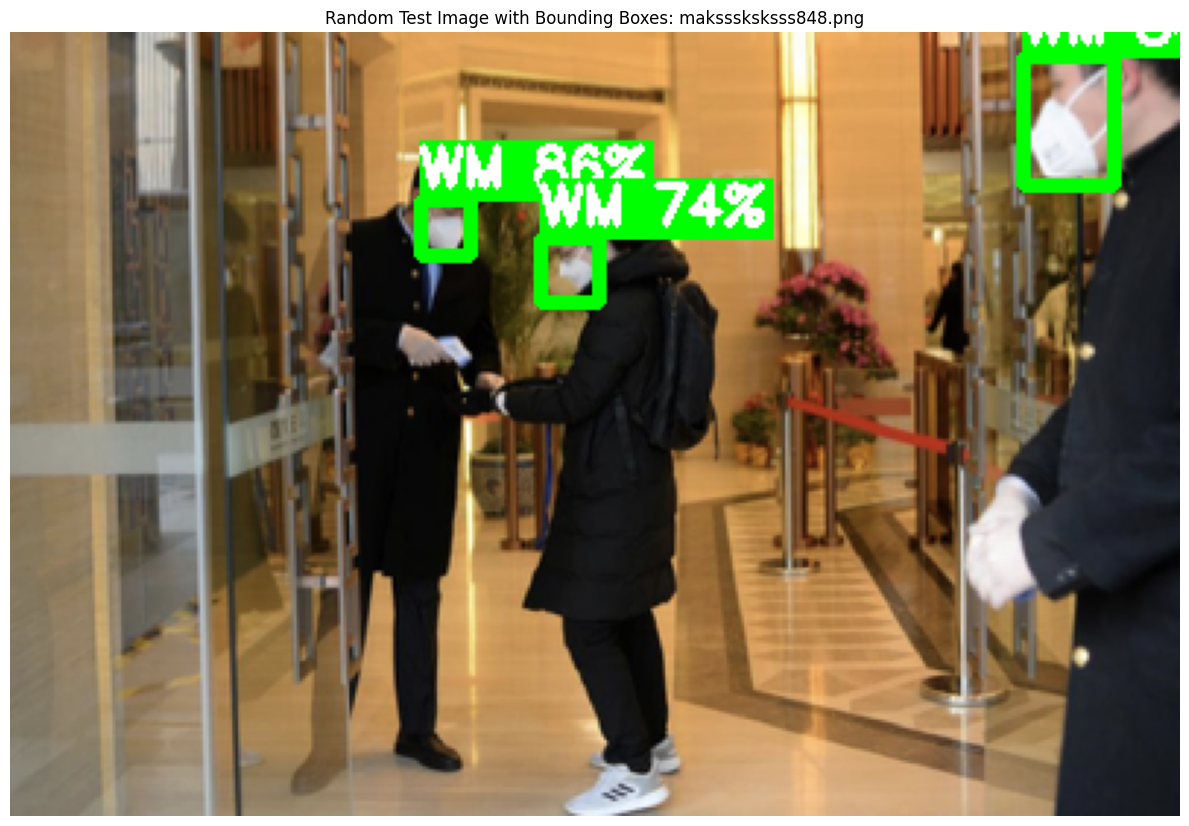

In [ ]:
# Cell 12 (final): Test model on a RANDOM TEST image with WM/WOM labels
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path
import random

best_model_path = "runs/detect/face_mask_yolov8n/weights/best.pt"
model_trained = YOLO(best_model_path)
class_names = model_trained.names

# ---- Choose a RANDOM test image ----
test_images_dir = Path("dataset/images/test")
test_image_paths = list(test_images_dir.glob("*.*"))

if len(test_image_paths) == 0:
    raise ValueError("No test images found in dataset/images/test")

# Pick a random image
test_image_path = random.choice(test_image_paths)
print("Testing on RANDOM TEST image:", test_image_path)

# Load original image
img = cv2.imread(str(test_image_path))
if img is None:
    raise ValueError("Could not load image. Check path.")

# Run prediction
results = model_trained.predict(source=str(test_image_path), conf=0.25, save=False)

print("\n=== PREDICTIONS ===")
for r in results:
    boxes = r.boxes
    if len(boxes) == 0:
        print("No faces detected.")
    else:
        for box in boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            class_name = class_names[cls]

            # Create short label: WM or WOM with percentage
            if class_name == "with_mask":
                label = f"WM {conf*100:.0f}%"
                color = (0, 255, 0)  # green
            else:
                label = f"WOM {conf*100:.0f}%"
                color = (0, 0, 255)  # red

            print(f"Class: {class_name}, Confidence: {conf:.2f} ({conf*100:.0f}%)")

            # Get bounding box coordinates
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Draw bounding box
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

            # Draw label background
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1 - 20), (x1 + w, y1), color, -1)

            # Draw label text
            cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

# Show image with bounding boxes
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)
plt.title(f"Random Test Image with Bounding Boxes: {test_image_path.name}")
plt.axis("off")
plt.tight_layout()
plt.show()

Testing on RANDOM TEST image: dataset/images/test/maksssksksss702.png

image 1/1 /content/dataset/images/test/maksssksksss702.png: 352x640 10 with_masks, 1 without_mask, 39.6ms
Speed: 1.6ms preprocess, 39.6ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)

=== PREDICTIONS ===
Class: with_mask, Confidence: 0.92 (92%)
Class: with_mask, Confidence: 0.91 (91%)
Class: with_mask, Confidence: 0.90 (90%)
Class: with_mask, Confidence: 0.86 (86%)
Class: with_mask, Confidence: 0.85 (85%)
Class: with_mask, Confidence: 0.85 (85%)
Class: with_mask, Confidence: 0.83 (83%)
Class: without_mask, Confidence: 0.75 (75%)
Class: with_mask, Confidence: 0.56 (56%)
Class: with_mask, Confidence: 0.48 (48%)
Class: with_mask, Confidence: 0.32 (32%)


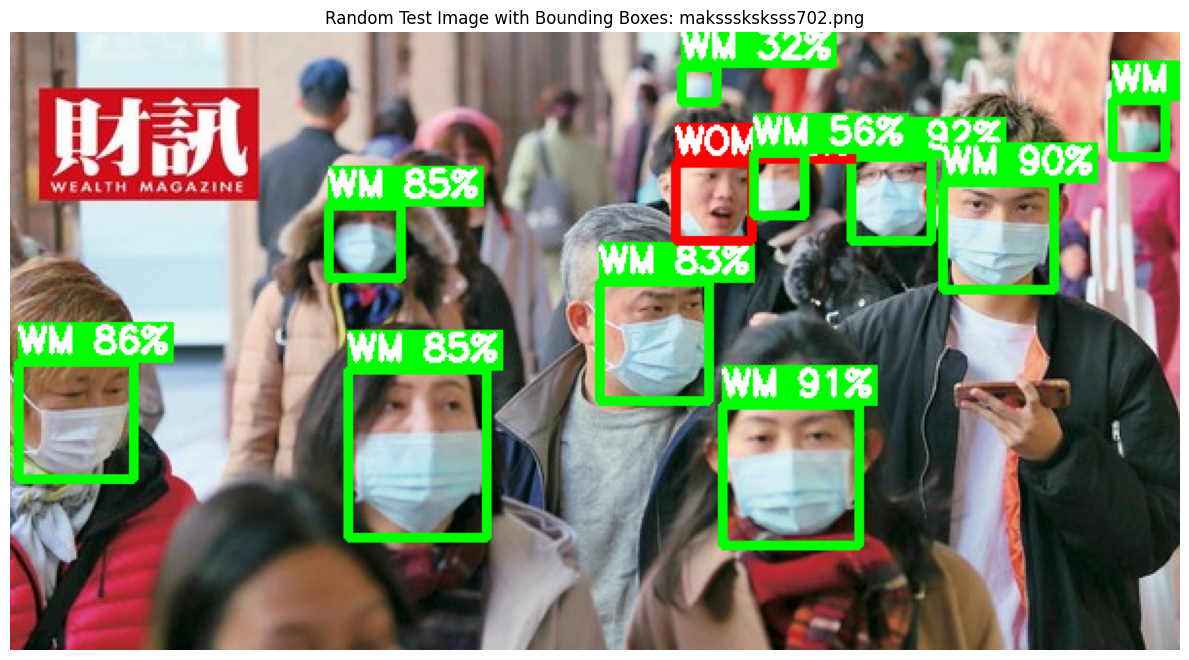

In [ ]:
# Cell 12 (final): Test model on a RANDOM TEST image with WM/WOM labels
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path
import random

best_model_path = "runs/detect/face_mask_yolov8n/weights/best.pt"
model_trained = YOLO(best_model_path)
class_names = model_trained.names

# ---- Choose a RANDOM test image ----
test_images_dir = Path("dataset/images/test")
test_image_paths = list(test_images_dir.glob("*.*"))

if len(test_image_paths) == 0:
    raise ValueError("No test images found in dataset/images/test")

# Pick a random image
test_image_path = random.choice(test_image_paths)
print("Testing on RANDOM TEST image:", test_image_path)

# Load original image
img = cv2.imread(str(test_image_path))
if img is None:
    raise ValueError("Could not load image. Check path.")

# Run prediction
results = model_trained.predict(source=str(test_image_path), conf=0.25, save=False)

print("\n=== PREDICTIONS ===")
for r in results:
    boxes = r.boxes
    if len(boxes) == 0:
        print("No faces detected.")
    else:
        for box in boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            class_name = class_names[cls]

            # Create short label: WM or WOM with percentage
            if class_name == "with_mask":
                label = f"WM {conf*100:.0f}%"
                color = (0, 255, 0)  # green
            else:
                label = f"WOM {conf*100:.0f}%"
                color = (0, 0, 255)  # red

            print(f"Class: {class_name}, Confidence: {conf:.2f} ({conf*100:.0f}%)")

            # Get bounding box coordinates
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Draw bounding box
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

            # Draw label background
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1 - 20), (x1 + w, y1), color, -1)

            # Draw label text
            cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

# Show image with bounding boxes
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)
plt.title(f"Random Test Image with Bounding Boxes: {test_image_path.name}")
plt.axis("off")
plt.tight_layout()
plt.show()


Upload an image from your local computer:


Saving Screenshot 2026-05-30 123959.png to Screenshot 2026-05-30 123959.png
Uploaded image: Screenshot 2026-05-30 123959.png

image 1/1 /content/Screenshot 2026-05-30 123959.png: 480x640 8 with_masks, 3 without_masks, 53.0ms
Speed: 2.7ms preprocess, 53.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

=== PREDICTIONS ===
Class: with_mask, Confidence: 0.93 (93%)
Class: with_mask, Confidence: 0.92 (92%)
Class: with_mask, Confidence: 0.92 (92%)
Class: with_mask, Confidence: 0.91 (91%)
Class: without_mask, Confidence: 0.91 (91%)
Class: with_mask, Confidence: 0.91 (91%)
Class: with_mask, Confidence: 0.90 (90%)
Class: with_mask, Confidence: 0.88 (88%)
Class: without_mask, Confidence: 0.85 (85%)
Class: with_mask, Confidence: 0.82 (82%)
Class: without_mask, Confidence: 0.65 (65%)


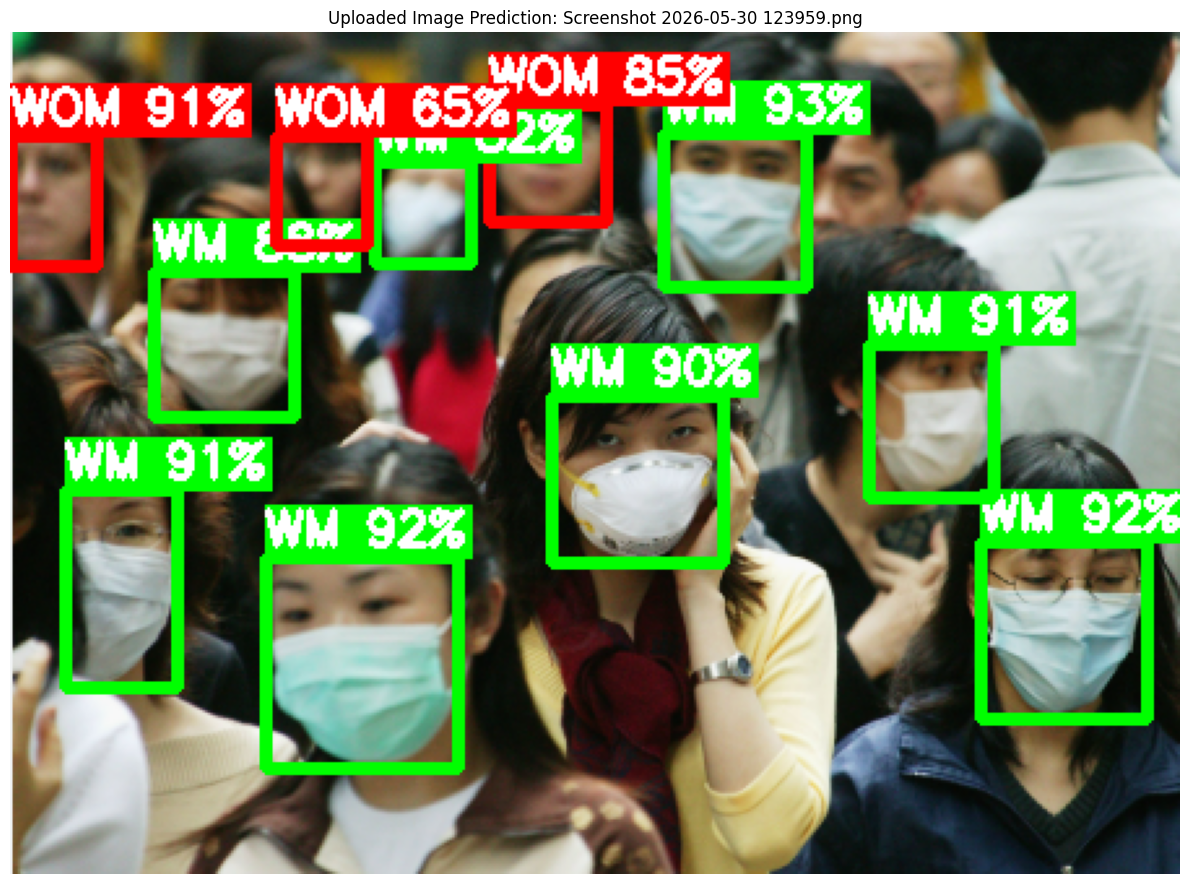

In [ ]:
# Cell 13: Upload a local image and predict with your trained model
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
import os

best_model_path = "runs/detect/face_mask_yolov8n/weights/best.pt"
model_trained = YOLO(best_model_path)
class_names = model_trained.names

print("Upload an image from your local computer:")
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No file uploaded. Please try again.")

# Get the uploaded filename
uploaded_filename = list(uploaded.keys())[0]
print(f"Uploaded image: {uploaded_filename}")

# Load the uploaded image
img = cv2.imread(uploaded_filename)
if img is None:
    raise ValueError("Could not load the uploaded image.")

# Run prediction
results = model_trained.predict(source=uploaded_filename, conf=0.25, save=False)

print("\n=== PREDICTIONS ===")
for r in results:
    boxes = r.boxes
    if len(boxes) == 0:
        print("No faces detected in this image.")
    else:
        for box in boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            class_name = class_names[cls]

            # Create short label: WM or WOM with percentage
            if class_name == "with_mask":
                label = f"WM {conf*100:.0f}%"
                color = (0, 255, 0)  # green
            else:
                label = f"WOM {conf*100:.0f}%"
                color = (0, 0, 255)  # red

            print(f"Class: {class_name}, Confidence: {conf:.2f} ({conf*100:.0f}%)")

            # Get bounding box coordinates
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Draw bounding box
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

            # Draw label background
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1 - 20), (x1 + w, y1), color, -1)

            # Draw label text
            cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

# Show image with bounding boxes
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)
plt.title(f"Uploaded Image Prediction: {uploaded_filename}")
plt.axis("off")
plt.tight_layout()
plt.show()

Upload an image from your local computer:


Saving Screenshot 2026-05-30 124517.png to Screenshot 2026-05-30 124517.png
Uploaded image: Screenshot 2026-05-30 124517.png

image 1/1 /content/Screenshot 2026-05-30 124517.png: 640x640 4 with_masks, 7.8ms
Speed: 3.3ms preprocess, 7.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

=== PREDICTIONS ===
Class: with_mask, Confidence: 0.93 (93%)
Class: with_mask, Confidence: 0.47 (47%)
Class: with_mask, Confidence: 0.46 (46%)
Class: with_mask, Confidence: 0.28 (28%)


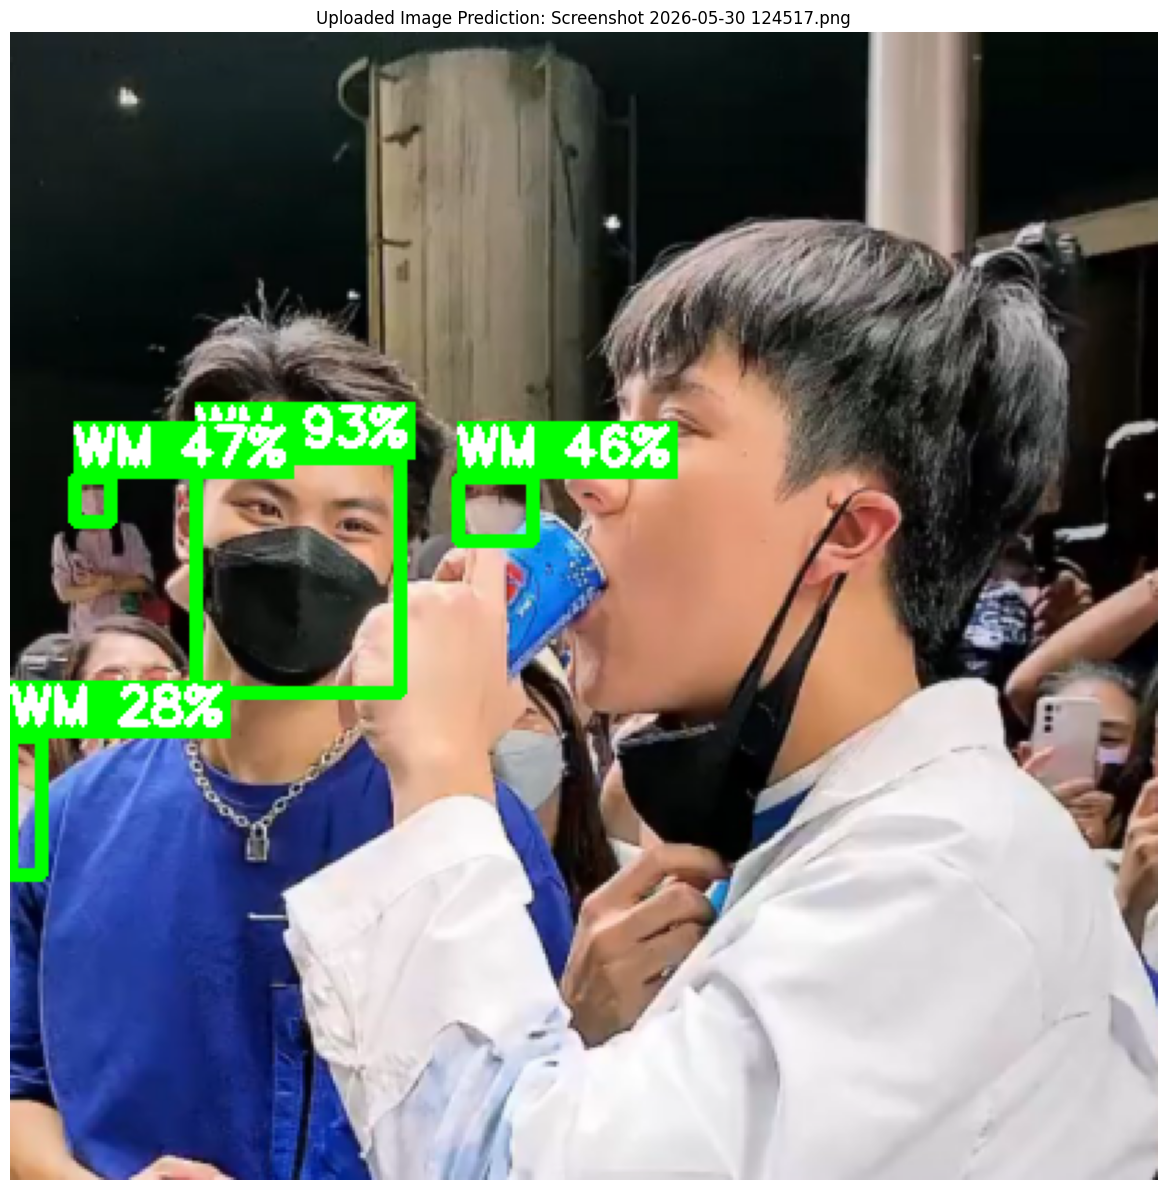

In [ ]:
# Cell 13: Upload a local image and predict with your trained model
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
import os

best_model_path = "runs/detect/face_mask_yolov8n/weights/best.pt"
model_trained = YOLO(best_model_path)
class_names = model_trained.names

print("Upload an image from your local computer:")
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No file uploaded. Please try again.")

# Get the uploaded filename
uploaded_filename = list(uploaded.keys())[0]
print(f"Uploaded image: {uploaded_filename}")

# Load the uploaded image
img = cv2.imread(uploaded_filename)
if img is None:
    raise ValueError("Could not load the uploaded image.")

# Run prediction
results = model_trained.predict(source=uploaded_filename, conf=0.25, save=False)

print("\n=== PREDICTIONS ===")
for r in results:
    boxes = r.boxes
    if len(boxes) == 0:
        print("No faces detected in this image.")
    else:
        for box in boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            class_name = class_names[cls]

            # Create short label: WM or WOM with percentage
            if class_name == "with_mask":
                label = f"WM {conf*100:.0f}%"
                color = (0, 255, 0)  # green
            else:
                label = f"WOM {conf*100:.0f}%"
                color = (0, 0, 255)  # red

            print(f"Class: {class_name}, Confidence: {conf:.2f} ({conf*100:.0f}%)")

            # Get bounding box coordinates
            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Draw bounding box
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

            # Draw label background
            (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1 - 20), (x1 + w, y1), color, -1)

            # Draw label text
            cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

# Show image with bounding boxes
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)
plt.title(f"Uploaded Image Prediction: {uploaded_filename}")
plt.axis("off")
plt.tight_layout()
plt.show()